# QLL exercise: learning physically consistent dice predictions

**Repository:** [property-driven-ml](https://github.com/property-driven-ml/property-driven-ml).
**Paper:** [Quantitative Linear Logic for Neuro-Symbolic Learning and Verification](https://arxiv.org/abs/2605.13845).

This notebook follows the Dice example from the repo and paper above using QLL to guide learning on the training images.
The main code is taken or adapted from the repo above.

You are given a dataset of images that show three faces of one die. The CNN receives a **28 × 28 RGB image** and produces
**six logits**, one for each face. A positive logit predicts that face is visible. This is multi-label
classification: the labels say which three faces actually appear. The standard die has 3 pairings of faces, 1 is opposite 6, 2 is opposite 5, and 3 is opposite of 4. Because of this physical feature, seeing 3 faces lets us know the full configuration of the die.  

We can introduce some logical constraints on the output of our network:

- **Not-Both:** opposite faces cannot both be visible.
- **At-Least-One per pair:** at least one face from each opposite pair must be visible.
- Combining these gives **Exactly-One per pair**.

**Question:** Could a prediction obey these rules and still name the wrong faces? **Answer:** I suppose yes, once we have 2 decided, the third will also be decided?

Please answer the questions of this notebook in a markdown cell and fill in the '#TO-DO' in python.

## 1. Additive QLL: equations to implement

In the additive domain of QLL, lower scores indicate greater constraint satisfaction: $-\infty$ represents truth ($\top$), while $+\infty$ represents falsehood ($\bot$). This matches the familiar notion that fitting to the data reduces the loss. 

Here $a,b$ below are scores, not images or class labels:

$$\operatorname{NOT}(a)=-a,$$
$$\operatorname{IMPL}(a,b)=a\multimap b=b-a.$$
$$\operatorname{AND}_p(a,b)=\frac1p\log(e^{pa}+e^{pb}),$$
$$\operatorname{OR}_p(a,b)=-\frac1p\log(e^{-pa}+e^{-pb}),\qquad p>0.$$

As $p$ grows, AND approaches max and OR approaches min.

## 2. Write the constraints

Let $V_i$ mean “face $i$ is predicted visible”, and let
$P=\{(1,6),(2,5),(3,4)\}$.

$\vee$ = "or", $\wedge$ = "and"

1. Write **Not-Both** for every pair: $\urcorner(V_1 \wedge V_6) \wedge \urcorner(V_2 \wedge V_3) \wedge \urcorner(V_2 \wedge V_5)$
2. Write **At-Least-One** for every pair: $(V_1 \vee V_6) \wedge (V_2 \vee V_5) \wedge (V_3 \vee V_4)$
3. Combine your two formulas to get **Exactly-One**: $(\urcorner(V_1 \wedge V_6) \wedge \urcorner(V_2 \wedge V_3) \wedge \urcorner(V_2 \wedge V_5)) \wedge ((V_1 \vee V_6) \wedge (V_2 \vee V_5) \wedge (V_3 \vee V_4)) = \bigwedge_{(i,j)\in P}\big((V_i\vee V_j)\big) \wedge \bigwedge_{(i,j)\in P}\big(\neg(V_i\wedge V_j)\big) = \bigwedge_{(i,j)\in P}\big((V_i\vee V_j)\wedge\neg(V_i\wedge V_j)\big)$

In [19]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "data/dice/labels.csv").exists():
    ROOT = ROOT / "qll-exercise"
assert (ROOT / "data/dice/labels.csv").exists(), "Open the notebook from the exercise folder."
device = torch.device("cpu")
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

## 3. Implement `qll`

Fill in the six methods below. Use the equations in section 1 for NOT, IMPL, AND and OR.
For comparisons, note that $-\infty$ represents truth ($\top$) and $+\infty$ represents falsehood ($\bot$). What operation will give us a negative value when the comparison is true.

Note: use PyTorch operations and `torch.logsumexp` for AND and OR.

In [20]:
class qll:
    def __init__(self, p=5.0):
        assert p > 0
        self.p = p

    def LEQ(self, a, b):
        return a - b

    def GEQ(self, a, b):
        return b - a

    def NOT(self, a):
        return -a

    def IMPL(self, a, b):
        return b - a

    def AND(self, *scores):
        return 1/self.p * torch.logsumexp(torch.stack(scores) * self.p, dim=0)

    def OR(self, *scores):
        return -1/self.p * torch.logsumexp(-torch.stack(scores) * self.p, dim=0)

logic = qll(p=5.0)

In [21]:
a, b = torch.tensor(1.0), torch.tensor(2.0)
assert logic.LEQ(a, b) == -1
assert logic.GEQ(a, b) == 1
assert logic.NOT(a) == -1
assert logic.IMPL(a, b) == 1
assert logic.AND(a, b) >= b
assert logic.OR(a, b) <= a
print("Looks good!")

Looks good!


## 4. Translate the dice rules into QLL

Complete the three postcondition classes using the constraints you wrote in section 2.
Combine the comparison scores with `logic.AND` and `logic.OR` to return one score per image.

For Not-Both, a face is absent when its logit is at most 0. For At-Least-One, require at least
one logit of 0.1 or more in each pair. Exactly-One combines this with a logit of −0.1 or less
for the other face in the pair.
The next cell shows how the rules behave for three example predictions.

In [22]:
PAIRS = [(0, 5), (1, 4), (2, 3)]

class NotBothPostcondition:
    def __init__(self, device):
        self.zero = torch.tensor(0.0, device=device)
        self.opposite_pairs = PAIRS

    def build_postcondition(self, N, x):
        logits = N(x)

        def _(logic):
            tmp = []
            for i, j in self.opposite_pairs:
                tmp.append(logic.NOT(
                    logic.AND(
                        logic.GEQ(logits[:, i], 0),
                        logic.GEQ(logits[:, j], 0)
                    )
                ))
            return logic.AND(*tmp)

        return _

class AtLeastOnePerPairPostcondition:
    def __init__(self, device):
        self.opposite_pairs = PAIRS

    def build_postcondition(self, N, x):
        logits = N(x)

        def _(logic):
            margin = 0.1
            tmp = []
            for i, j in self.opposite_pairs:
                tmp.append(logic.OR(
                    logic.GEQ(logits[:, i], margin),
                    logic.GEQ(logits[:, j], margin)
                ))
            return logic.AND(*tmp)

        return _

class ExactlyOnePerPairPostcondition:
    def __init__(self, device):
        self.opposite_pairs = PAIRS

    def build_postcondition(self, N, x):
        logits = N(x)

        def _(logic):
            margin = 0.1
            constraints = []
            for i, j in self.opposite_pairs:
                constraints.append(
                    logic.AND(
                        logic.NOT(logic.AND(
                            logic.GEQ(logits[:, i], 0),
                            logic.GEQ(logits[:, j], 0)
                        )),
                        logic.OR(
                            logic.GEQ(logits[:, i], margin),
                            logic.GEQ(logits[:, j], margin)
                        )
                    )
                )
            return logic.AND(*constraints)

        return _

RULES = {"Not-Both": NotBothPostcondition(device),
         "At-Least-One": AtLeastOnePerPairPostcondition(device),
         "Exactly-One": ExactlyOnePerPairPostcondition(device)}

In [23]:
def holds(logits, property_name):
    visible = (logits > 0).int()
    valid = torch.ones(len(logits), dtype=torch.bool, device=logits.device)
    for i, j in PAIRS:
        count = visible[:, i] + visible[:, j]
        if property_name == "Not-Both":
            valid &= count <= 1
        elif property_name == "At-Least-One":
            valid &= count >= 1
        else:  # Exactly-One
            valid &= count == 1
    return valid

examples = torch.tensor([
    [ 1.,  1.,  1., -1., -1., -1.],  # faces 1, 2, 3
    [ 1.,  1.,  1.,  1.,  1.,  1.],  # all six faces
    [-1., -1., -1., -1., -1., -1.],  # no faces
])
assert holds(examples, "Not-Both").tolist() == [True, False, True]
assert holds(examples, "Exactly-One").tolist() == [True, False, False]
assert holds(examples, "At-Least-One").tolist() == [True, True, False]

## 5. Load the dice data

Run this cell to define the data loader and view some labelled images.
The loader will split the 340 images into 272 training images and 68 test images.
Normalization and training-image augmentation are already provided.

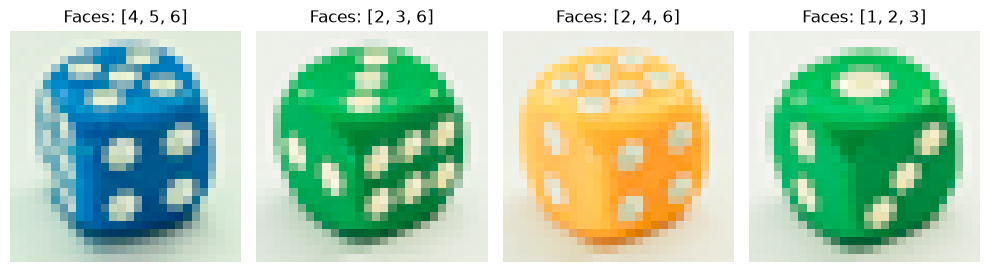

In [24]:
import os
from typing import Tuple
import pandas as pd

class DiceDataset(torch.utils.data.Dataset):
    def __init__(
        self, csv_path: str, image_dir: str, transform=None, indices: np.ndarray = None
    ):
        self.data = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.transform = transform

        self.data = self.data.iloc[indices].reset_index(drop=True)

    def get_mean_std(self) -> Tuple[Tuple[float, ...], Tuple[float, ...]]:
        imgs = []

        for row in self.data.itertuples():
            img_path = os.path.join(self.image_dir, str(row.filename))
            img = Image.open(img_path).convert("RGB")
            img = np.asarray(img, dtype=np.float32) / 255.0
            imgs.append(img)

        imgs = np.stack(imgs)
        return tuple(imgs.mean(axis=(0, 1, 2)).tolist()), tuple(
            imgs.std(axis=(0, 1, 2)).tolist()
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.image_dir, row["filename"])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(row.iloc[1:].to_numpy(dtype=np.float32))
        return image, labels

def create_dice_datasets(
    batch_size: int, train_split: float = 0.8, normalise: bool = True,
    seed: int = 42, loader_seed: int = 0
):
    csv_path = ROOT / "data/dice/labels.csv"
    image_dir = ROOT / "data/dice"

    data_all = pd.read_csv(csv_path)

    perm = np.random.RandomState(seed).permutation(len(data_all))
    split_idx = int(train_split * len(data_all))
    train_idx, test_idx = perm[:split_idx], perm[split_idx:]

    mean, std = DiceDataset(csv_path, image_dir, indices=train_idx).get_mean_std()

    train_transforms: list = [
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.03),
        transforms.ToTensor(),
    ]

    test_transforms: list = [
        transforms.ToTensor(),
    ]

    if normalise:
        train_transforms.append(transforms.Normalize(mean, std))
        test_transforms.append(transforms.Normalize(mean, std))

    dataset_train = DiceDataset(
        csv_path,
        image_dir,
        transform=transforms.Compose(train_transforms),
        indices=train_idx,
    )
    dataset_test = DiceDataset(
        csv_path,
        image_dir,
        transform=transforms.Compose(test_transforms),
        indices=test_idx,
    )

    train_loader = DataLoader(
        dataset_train, batch_size=batch_size, shuffle=True,
        generator=torch.Generator().manual_seed(loader_seed),
    )
    test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

    model = DiceNet()
    return train_loader, test_loader, model, (mean, std)


preview_ids = np.random.RandomState(42).permutation(340)[:4]
preview = DiceDataset(ROOT / "data/dice/labels.csv", ROOT / "data/dice", indices=preview_ids)
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for ax, (image, label) in zip(axes, preview):
    ax.imshow(image)
    ax.set_title(f"Faces: {(label.nonzero().flatten() + 1).tolist()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. The model

Run the provided `DiceNet` class. It takes an RGB image and returns six logits, one for each face.

In [25]:
class DiceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 4, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(8 * 7 * 7, 16)
        self.fc2 = nn.Linear(16, 6)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.conv2(x)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## 7. QLL belongs in the training loss

Complete `combined_loss` so that it adds the supervised loss to the weighted QLL loss:

$$L_{\mathrm{total}}=L_{\mathrm{supervised}}+\lambda L_{\mathrm{QLL}}.$$

**Question:** Which loss term needs the ground-truth labels? **Answer:** Only the supervised loss needs the ground truth label, as it is the only one that is directly relating to the specific answer. The QLL loss i simply whether the given answer is feasible, not whether it is correct.

In [26]:
def combined_loss(supervised, logical, weight):
    return supervised + weight * logical

### Loss weight and run settings

Run the provided helper. The training loop uses it to balance the supervised and QLL gradients
when choosing the loss weight. For a shorter run, change `SEEDS` below to `[0]`.

In [27]:
def gradnorm(loss, params):
    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        create_graph=False,
        allow_unused=True,
    )

    grads = [g.detach().norm() for g in grads if g is not None]

    if len(grads) == 0:
        return torch.tensor(0.0, device=loss.device)

    return torch.norm(torch.stack(grads))

In [28]:
EPOCHS = 100
SEEDS = [0, 1, 2, 3, 4]
OUTPUT = ROOT / "outputs/notebook"
OUTPUT.mkdir(parents=True, exist_ok=True)

## 8. The training loop

Run this cell to define one training epoch. Read through the loop and find where it calls
your `combined_loss` before backpropagation. When `with_dl` is `False`, it uses only the supervised loss.

In [29]:
def train(epoch, N, device, train_loader, optimizer, logic, constraint, with_dl, alpha=0.5):
    N.train()
    for data, target in train_loader:
        x, y_target = data.to(device), target.to(device)
        y = N(x)
        loss = F.binary_cross_entropy_with_logits(y, y_target)
        optimizer.zero_grad(set_to_none=True)

        if not with_dl:
            loss.backward()
            optimizer.step()
        else:
            loss_pred = loss
            loss_logic_train = torch.mean(constraint.build_postcondition(N, x)(logic))
            params = list(N.fc2.parameters())
            g_pred = gradnorm(loss_pred, params)
            g_logic = gradnorm(loss_logic_train, params)
            w_logic = alpha * g_pred / (g_logic + 1e-8) # defines the weight given to the QLL logic
            w_logic = torch.clamp(w_logic, max=10.0)
            total_loss = combined_loss(loss_pred, loss_logic_train, w_logic)
            total_loss.backward()
            optimizer.step()

## 9. Measure accuracy and consistency separately

Run the evaluation cell. Compare the models using three measures:

- **PAcc:** percentage of individual face labels predicted correctly.
- **Exact set:** percentage of images whose entire set of face labels is correct.
- **Property evaluated:** percentage of test images whose predictions obey each rule, regardless of the training method.

In [30]:
@torch.no_grad()
def test(N, device, test_loader):
    N.eval()
    correct, exact, total_samples = 0.0, 0, 0
    satisfied = {name: 0 for name in RULES}
    for data, target in test_loader:
        x, y_target = data.to(device), target.to(device)
        y = N(x)
        pred = (y > 0.0).float()
        correct += (pred == y_target).float().mean(dim=1).sum().item()
        exact += (pred == y_target).all(dim=1).sum().item()
        total_samples += x.size(0)
        for name in RULES:
            satisfied[name] += holds(y, name).sum().item()
    return {"PAcc": 100 * correct / total_samples,
            "Exact set": 100 * exact / total_samples,
            **{name: 100 * count / total_samples for name, count in satisfied.items()}}

## 10. Run and compare

This trains a supervised baseline and a separate
QLL model for each constraint: Not-Both, At-Least-One and Exactly-One.

Compare prediction accuracy, exact-set accuracy and rule satisfaction in the table, then inspect the three learning curves. Adjust the model hyperparameters and comment on the results, i.e. change the weight of QLL loss, number of epochs trained, or model architecture. 


In [31]:
def run_experiment(property_name, seed):
    torch.manual_seed(seed)
    train_loader, test_loader, N, (mean, std) = create_dice_datasets(
        batch_size=16, seed=42, loader_seed=seed)
    N = N.to(device)
    optimizer = torch.optim.AdamW(N.parameters(), lr=1e-3, weight_decay=1e-4)
    constraint = RULES.get(property_name)
    history = []
    started = time.perf_counter()
    for epoch in range(1, EPOCHS + 1):
        train(epoch, N, device, train_loader, optimizer, logic,
              constraint, with_dl=constraint is not None)
        history.append({"epoch": epoch, **test(N, device, test_loader)})
        if epoch % 25 == 0 or epoch == EPOCHS:
            print(f"seed {seed} | {property_name or 'Supervised'} | epoch {epoch} | "
                  f"accuracy {history[-1]['PAcc']:.1f}%", flush=True)
    return N, history, time.perf_counter() - started

runs, histories = [], {}
for seed in SEEDS:
    baseline, history, baseline_seconds = run_experiment(None, seed)
    histories[(seed, "Supervised")] = history
    baseline_metrics = history[-1]
    torch.save(baseline.state_dict(), OUTPUT / f"seed-{seed}-baseline.pt")
    for property_name in RULES:
        runs.append({"property": property_name, "method": "Supervised", "seed": seed,
                     "seconds": baseline_seconds, "PAcc": baseline_metrics["PAcc"],
                     "Exact set": baseline_metrics["Exact set"],
                     "Rule satisfied": baseline_metrics[property_name]})
        model, history, seconds = run_experiment(property_name, seed)
        histories[(seed, property_name)] = history
        runs.append({"property": property_name, "method": "Supervised + QLL", "seed": seed,
                     "seconds": seconds, "PAcc": history[-1]["PAcc"],
                     "Exact set": history[-1]["Exact set"],
                     "Rule satisfied": history[-1][property_name]})
        torch.save(model.state_dict(), OUTPUT / f"seed-{seed}-{property_name}.pt")

config = {"epochs": EPOCHS, "seeds": SEEDS, "p": logic.p, "split_seed": 42,
          "data": "original training images with colour jitter",
          "normalization": "upstream dataset transforms", "alpha": 0.5,
          "properties": list(RULES)}
(OUTPUT / "results.json").write_text(json.dumps({"config": config, "runs": runs}, indent=2))
print("Saved measured results:", OUTPUT / "results.json")
history_records = [{"seed": seed, "training": name, "epochs": history}
                   for (seed, name), history in histories.items()]
(OUTPUT / "histories.json").write_text(json.dumps(history_records, indent=2))


seed 0 | Supervised | epoch 25 | accuracy 77.9%
seed 0 | Supervised | epoch 50 | accuracy 83.8%
seed 0 | Supervised | epoch 75 | accuracy 83.3%
seed 0 | Supervised | epoch 100 | accuracy 83.6%
seed 0 | Not-Both | epoch 25 | accuracy 68.9%
seed 0 | Not-Both | epoch 50 | accuracy 77.5%
seed 0 | Not-Both | epoch 75 | accuracy 79.2%
seed 0 | Not-Both | epoch 100 | accuracy 79.7%
seed 0 | At-Least-One | epoch 25 | accuracy 72.1%
seed 0 | At-Least-One | epoch 50 | accuracy 85.0%
seed 0 | At-Least-One | epoch 75 | accuracy 86.0%
seed 0 | At-Least-One | epoch 100 | accuracy 85.3%
seed 0 | Exactly-One | epoch 25 | accuracy 68.9%
seed 0 | Exactly-One | epoch 50 | accuracy 83.1%
seed 0 | Exactly-One | epoch 75 | accuracy 83.1%
seed 0 | Exactly-One | epoch 100 | accuracy 82.8%
seed 1 | Supervised | epoch 25 | accuracy 75.2%
seed 1 | Supervised | epoch 50 | accuracy 82.4%
seed 1 | Supervised | epoch 75 | accuracy 82.1%
seed 1 | Supervised | epoch 100 | accuracy 83.1%
seed 1 | Not-Both | epoch 25 | 

458459

Accuracy              Property evaluated  \
                                 PAcc    Exact set           Not-Both   
Training                                                                
Supervised                 83.1 ± 2.7   62.9 ± 4.6         98.5 ± 1.8   
Supervised + Not-Both      82.7 ± 4.3   55.0 ± 6.9         99.4 ± 0.8   
Supervised + At-Least-One  84.1 ± 3.7   59.4 ± 8.2         85.3 ± 5.1   
Supervised + Exactly-One   82.2 ± 4.8  59.7 ± 11.7         98.5 ± 1.0   

                                                    
                          At-Least-One Exactly-One  
Training                                            
Supervised                  97.4 ± 1.9  95.9 ± 2.6  
Supervised + Not-Both       82.1 ± 8.0  81.5 ± 8.7  
Supervised + At-Least-One  100.0 ± 0.0  85.3 ± 5.1  
Supervised + Exactly-One    97.4 ± 2.2  95.9 ± 2.4

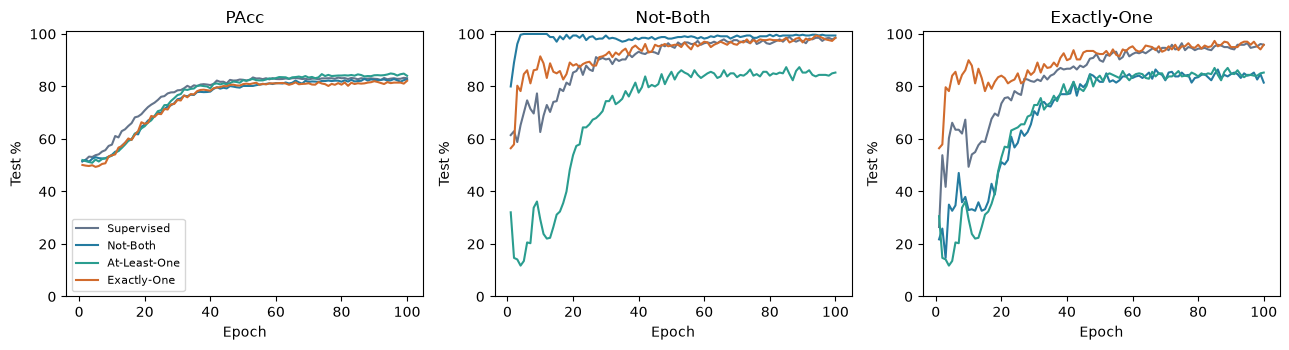

In [32]:
metrics = ["PAcc", "Exact set", *RULES]
rows, labels = [], []
for name in ["Supervised", *RULES]:
    selected = [histories[(seed, name)][-1] for seed in SEEDS]
    values = []
    for metric in metrics:
        xs = np.array([r[metric] for r in selected])
        values.append(f"{xs.mean():.1f} ± {xs.std(ddof=1):.1f}" if len(xs) > 1 else f"{xs[0]:.1f}")
    rows.append(values)
    labels.append("Supervised" if name == "Supervised" else f"Supervised + {name}")

columns = pd.MultiIndex.from_tuples(
    [("Accuracy", "PAcc"), ("Accuracy", "Exact set")]
    + [("Property evaluated", name) for name in RULES]
)
table = pd.DataFrame(rows, index=pd.Index(labels, name="Training"), columns=columns)
display(table)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for name, color in [("Supervised", "#64748b"), ("Not-Both", "#247ba0"), ("At-Least-One", "#2a9d8f"), ("Exactly-One", "#d16b2d")]:
    for ax, metric in zip(axes, ["PAcc", "Not-Both", "Exactly-One"]):
        curves = np.array([[h[metric] for h in histories[(seed, name)]] for seed in SEEDS])
        ax.plot(np.arange(1, EPOCHS + 1), curves.mean(0), label=name, color=color)
        ax.set(xlabel="Epoch", ylabel="Test %", title=metric, ylim=(0, 101))
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()